In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

I0000 00:00:1776527663.701664   52741 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776527663.763465   52741 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776527665.646562   52741 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

E0000 00:00:1776527681.286265   52741 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776527681.286629   53118 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776527681.307304   52741 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


In [6]:

IMAGE_DIR = r"caltech-101/accordion"

In [7]:
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    features = model.predict(img_array)
    return features.flatten()


In [8]:
features_db = {}
image_paths = []

for img_name in tqdm(os.listdir(IMAGE_DIR)):
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    if img_name.endswith((".jpg", ".png", ".jpeg")):
        features_db[img_name] = extract_features(img_path, model)
        image_paths.append(img_path)


  0%|          | 0/55 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  2%|▏         | 1/55 [00:00<00:08,  6.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  4%|▎         | 2/55 [00:00<00:07,  6.67it/s]

...

 96%|█████████▋| 53/55 [00:07<00:00,  6.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


 98%|█████████▊| 54/55 [00:07<00:00,  6.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


100%|██████████| 55/55 [00:07<00:00,  7.02it/s]


In [9]:
np.save("small_dataset_features.npy", features_db)

In [10]:
def search_similar_images(query_image_path, top_n=5):
    query_features = extract_features(query_image_path, model)
    
    similarities = {}
    
    for img_name, features in features_db.items():
        similarity = cosine_similarity([query_features], [features])[0][0]
        similarities[img_name] = similarity
    
    sorted_images = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    # Display results
    plt.figure(figsize=(15, 5))
    
    # Show query image
    plt.subplot(1, top_n + 1, 1)
    query_img = cv2.imread(query_image_path)[:, :, ::-1]
    plt.imshow(query_img)
    plt.axis('off')
    plt.title("Query Image")
    
    # Show similar images
    for i, (img_name, similarity) in enumerate(sorted_images):
        img = cv2.imread(os.path.join(IMAGE_DIR, img_name))[:, :, ::-1]
        
        plt.subplot(1, top_n + 1, i + 2)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sim: {similarity:.2f}")
    
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


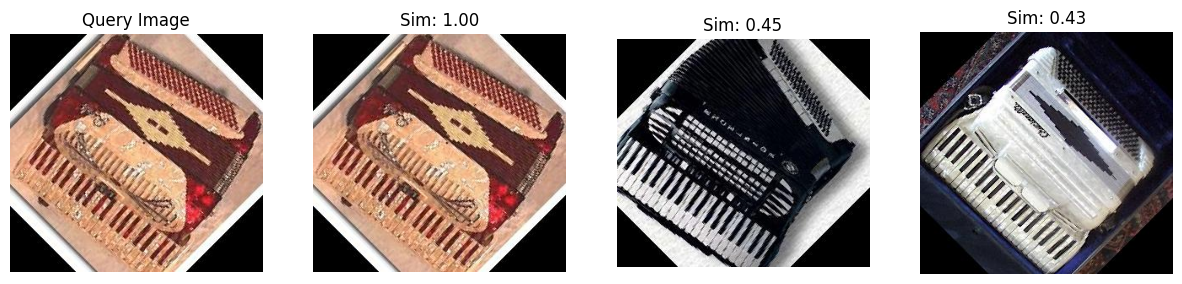

In [11]:
query_image = "caltech-101/accordion/image_0003.jpg"
search_similar_images(query_image, top_n=3)